# 03 — Diabetes Prediction: VitalsAI

This notebook trains a **Stacking Ensemble Model** (RF + XGBoost + LR) on the **Pima Indians Diabetes dataset** with StandardScaler preprocessing.

**Key steps:**
- Exploratory Data Analysis (EDA)
- StandardScaler normalization
- SMOTE for class imbalance
- Stacking Ensemble training
- Threshold optimization
- Model saving for VitalsAI deployment

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings, joblib, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score,
                              balanced_accuracy_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from collections import Counter

print('Libraries loaded ✅')
!pip install scikit-learn==1.6.1 xgboost==3.2.0 -q


Libraries loaded ✅


## 2. Load Dataset
Loading Pima Indians Diabetes dataset from Google Drive.

**Features:** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
**Target:** Outcome (0 = No Diabetes, 1 = Diabetes)

In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

import pandas as pd

# Path where your file is stored in Drive
df = pd.read_csv("/content/drive/MyDrive/diabetes.csv")

Mounted at /content/drive


## 3. Exploratory Data Analysis (EDA)
### 3.1 Basic Info & Shape

In [3]:
# Shape and first rows
print(df.shape)


(768, 9)


In [4]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [5]:
# Dataset info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [6]:
# Summary statistics
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

### 3.2 Missing Values

In [7]:
# Check missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### 3.3 Class Distribution — Diabetes Outcome

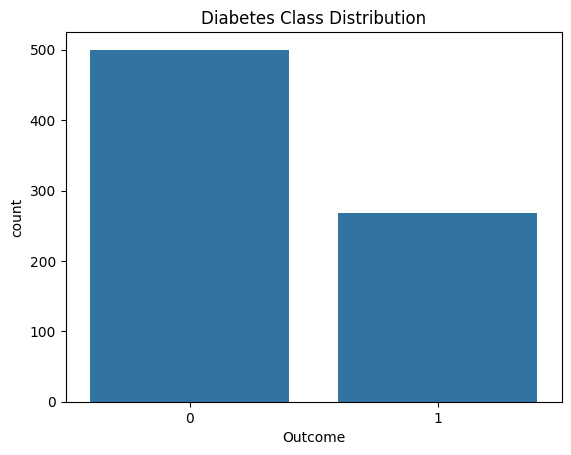

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Outcome distribution
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Class Distribution")
plt.show()

### 3.4 Feature Distributions — Histograms

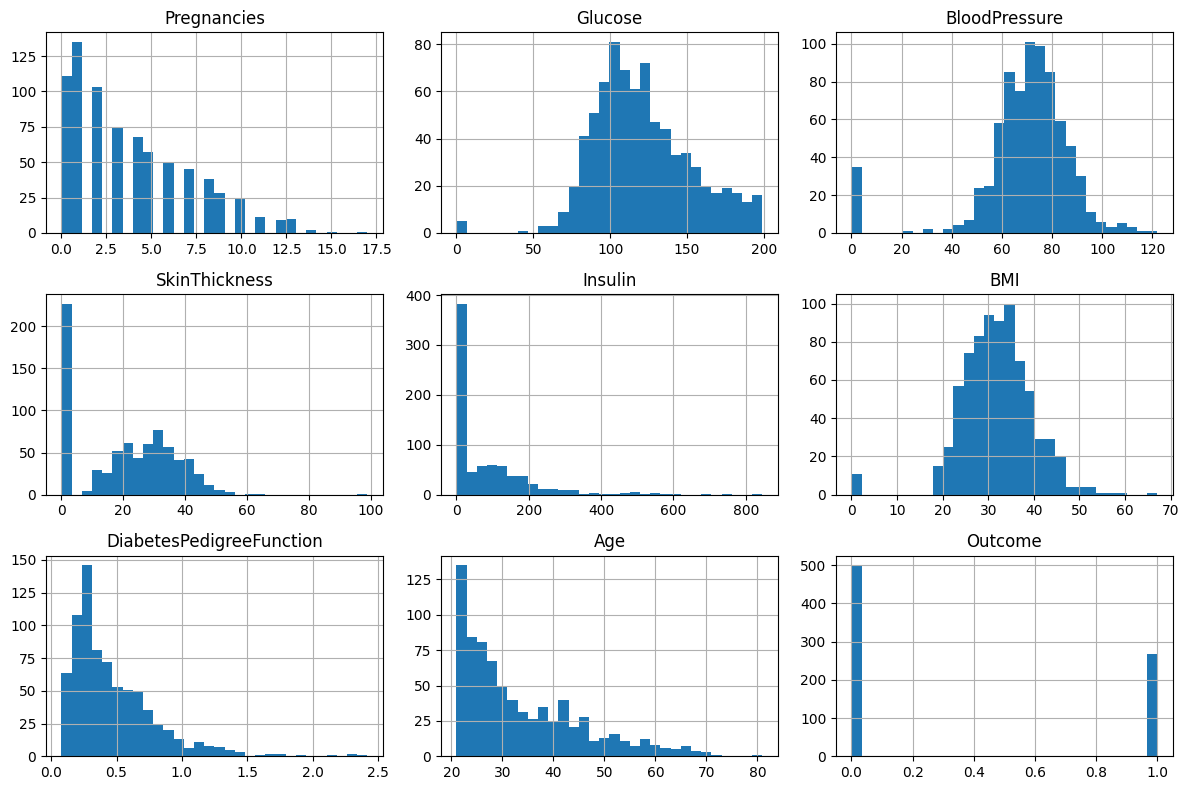

In [9]:
# Histograms for all features
df.hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap

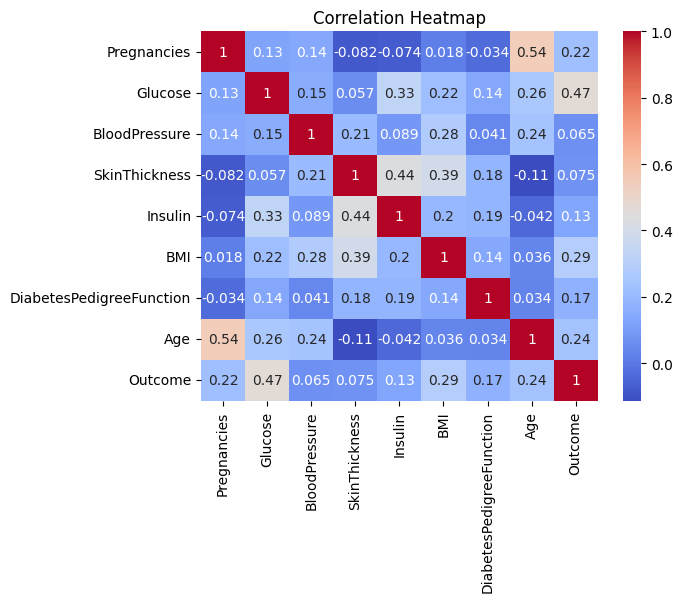

In [10]:
# Correlation heatmap
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

## 4. Preprocessing — StandardScaler + SMOTE
Applying StandardScaler normalization and SMOTE oversampling to handle class imbalance.

In [11]:

import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Replace '0' with NaN (Not a Number) in specific columns
# We do this so we can calculate the true median (ignoring the zeros)
cols_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_missing_vals] = df[cols_missing_vals].replace(0, np.nan)

# 2. Fill NaN values with the Median of that column
# Using median is safer than mean because it is less affected by outliers
for col in cols_missing_vals:
    df[col] = df[col].fillna(df[col].median())

print("Missing values handled. Checking for nulls again:")
print(df.isnull().sum())

Missing values handled. Checking for nulls again:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [12]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

feature_names = list(X.columns)
print('Features:', feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE on raw data (scaler apply thase pachhi)
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('Before SMOTE:', Counter(y_train))
print('After  SMOTE:', Counter(y_train_res))

# StandardScaler — SMOTE pachhi apply karo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)
print('Scaling done ✅')


Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Before SMOTE: Counter({0: 400, 1: 214})
After  SMOTE: Counter({0: 400, 1: 400})
Scaling done ✅


## 5. Stacking Ensemble Model
Base learners: Random Forest + XGBoost + SVC
Meta-learner: Logistic Regression (class_weight=balanced)

In [13]:
from xgboost import XGBClassifier

# Strong base learners
estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        max_depth=8,
        min_samples_leaf=2,
        random_state=42
    )),
    ('xgb', XGBClassifier(
        n_estimators=200,
        scale_pos_weight=1.8,  # diabetes ratio ~65:35
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )),
    ('gb', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42
    )),
    ('svc', make_pipeline(
        StandardScaler(),
        SVC(probability=True, class_weight='balanced', kernel='rbf', C=1.0, random_state=42)
    ))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        C=0.5
    ),
    cv=5,
    stack_method='predict_proba'
)

# Train on scaled SMOTE data
stack_model.fit(X_train_scaled, y_train_res)
print('Diabetes stacking model trained ✅')

# Evaluation
y_pred = stack_model.predict(X_test_scaled)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}')


Diabetes stacking model trained ✅

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.83      0.77      0.80       100
    Diabetes       0.62      0.70      0.66        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Balanced Accuracy: 0.7369


## 6. Model Evaluation
### 6.1 Threshold Analysis

In [14]:
# ── Threshold Analysis ────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

y_proba = stack_model.predict_proba(X_test_scaled)[:, 1]

print(f'{"-"*60}')
print(f'{"Threshold":<12} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print(f'{"-"*60}')
for t in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_t = (y_proba >= t).astype(int)
    p  = precision_score(y_test, y_t, zero_division=0)
    r  = recall_score(y_test, y_t, zero_division=0)
    f1 = f1_score(y_test, y_t, zero_division=0)
    print(f'{t:<12.2f} {p:>10.3f} {r:>8.3f} {f1:>8.3f}')

BEST_THRESHOLD = 0.40
y_pred_thresh = (y_proba >= BEST_THRESHOLD).astype(int)
print(f'\nUsing threshold: {BEST_THRESHOLD}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')


------------------------------------------------------------
Threshold     Precision   Recall       F1
------------------------------------------------------------
0.30              0.608    0.833    0.703
0.35              0.614    0.796    0.694
0.40              0.612    0.759    0.678
0.45              0.619    0.722    0.667
0.50              0.623    0.704    0.661
0.55              0.618    0.630    0.624
0.60              0.654    0.630    0.642

Using threshold: 0.4
ROC-AUC: 0.8289


### 6.2 Confusion Matrix

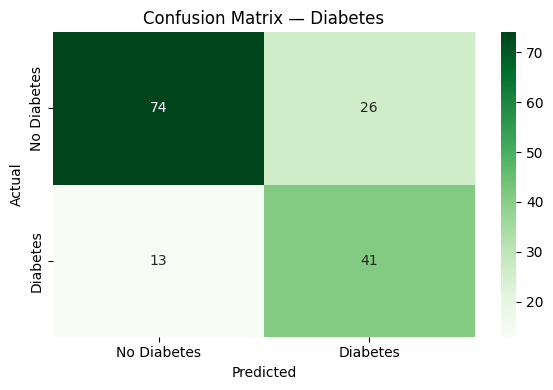

In [15]:
# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_thresh)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Diabetes')
plt.tight_layout(); plt.show()


### 6.3 ROC Curve

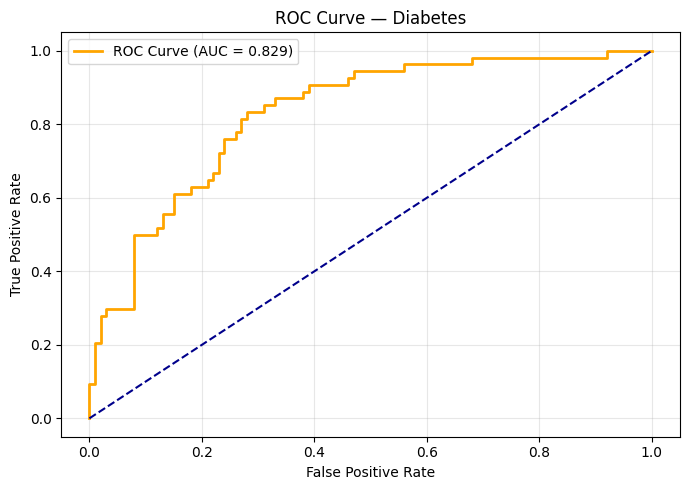

In [16]:
# ── ROC Curve ─────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0,1],[0,1],'--', color='darkblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Diabetes')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 6.4 Classification Report

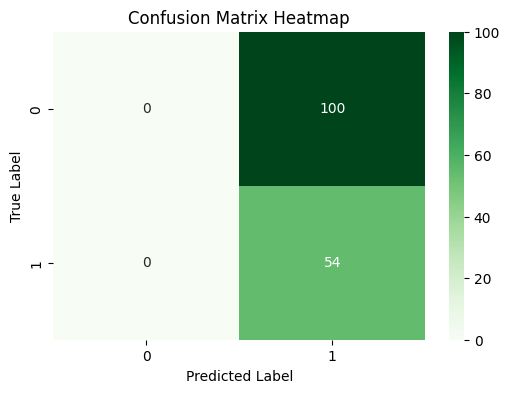

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predict on test set
y_pred = stack_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens",
            xticklabels=[0,1], yticklabels=[0,1])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


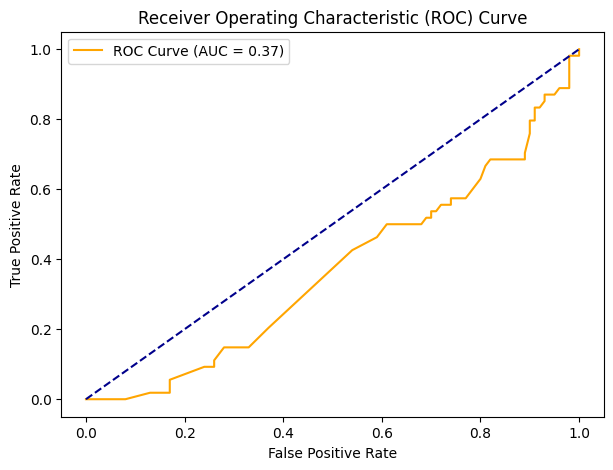

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

# મોડેલ પાસેથી પ્રોબેબિલિટી મેળવો
y_pred_proba = stack_model.predict_proba(X_test)[:, 1]

# ROC Curve ના પેરામીટર્સ
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# ગ્રાફ પ્લોટ કરો
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


### 6.5 Feature Importance

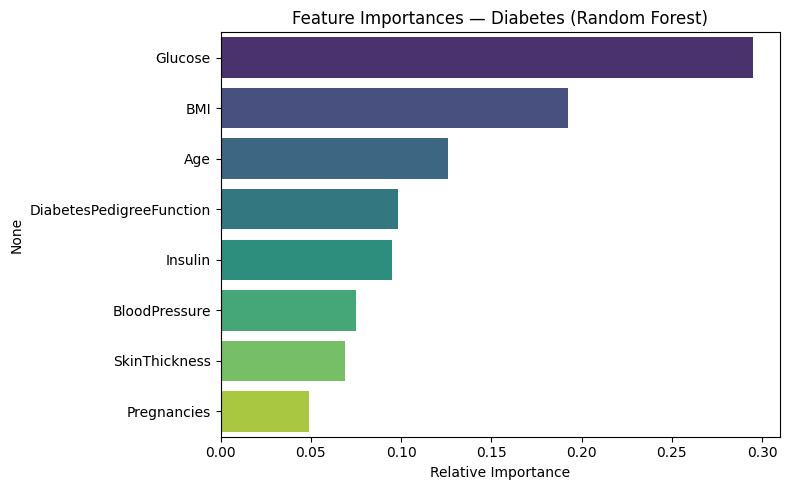

Top features: ['Glucose', 'BMI', 'Age']


In [20]:
# ── Feature Importance ────────────────────────────────────
rf_model    = stack_model.named_estimators_['rf']
importances = rf_model.feature_importances_

# feature_names use karo — X.columns nahi (length match mate)
feat_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_df.values, y=feat_df.index, palette='viridis')
plt.xlabel('Relative Importance')
plt.title('Feature Importances — Diabetes (Random Forest)')
plt.tight_layout(); plt.show()

print('Top features:', feat_df.head(3).index.tolist())


### 6.6 Precision-Recall Curve

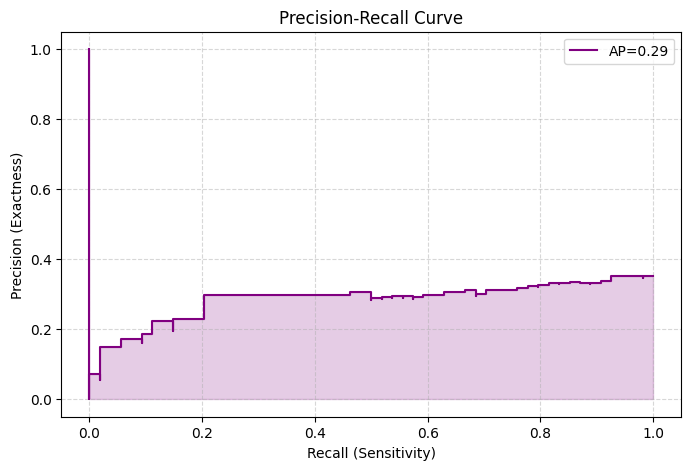

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# probability
y_score = stack_model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_score)
average_precision = average_precision_score(y_test, y_score)

# ploting
plt.figure(figsize=(8, 5))
plt.step(recall, precision, where='post', color='purple', label=f'AP={average_precision:.2f}')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='purple')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Exactness)')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## 7. Save Model for VitalsAI Deployment
Saving: `diabetes_stack_model.pkl`, `diabetes_scaler.pkl`

In [19]:
import joblib, os

# Local save
os.makedirs('models', exist_ok=True)
joblib.dump(stack_model, 'models/diabetes_stack_model.pkl')
joblib.dump(scaler,      'models/diabetes_scaler.pkl')
print('Saved locally ✅')

# Google Drive save
try:
    os.makedirs('/content/drive/MyDrive/VitalsAI_models', exist_ok=True)
    joblib.dump(stack_model, '/content/drive/MyDrive/VitalsAI_models/diabetes_stack_model.pkl')
    joblib.dump(scaler,      '/content/drive/MyDrive/VitalsAI_models/diabetes_scaler.pkl')
    print('Saved to Google Drive ✅')
except Exception as e:
    print(f'Drive save skipped: {e}')

print('\nFiles to copy to VitalsAI/models/:')
print('  ✅ diabetes_stack_model.pkl')
print('  ✅ diabetes_scaler.pkl')


Saved locally ✅
Saved to Google Drive ✅

Files to copy to VitalsAI/models/:
  ✅ diabetes_stack_model.pkl
  ✅ diabetes_scaler.pkl


## 8. Sample Prediction Test

In [21]:
# નવો ડેટા (Warning વગર)
sample_input = [[6, 150, 72, 35, 0, 33.6, 0.627, 50]]
sample_df = pd.DataFrame(sample_input, columns=X.columns) # ફીચરના નામ સાથે

# Scaling અને Prediction
sample_scaled = scaler.transform(sample_df)
prediction = stack_model.predict(sample_scaled)

print(f"Prediction Result: {'Diabetes' if prediction[0]==1 else 'No Diabetes'}")



Prediction Result: Diabetes


In [23]:
# ── Manual Patient Test ───────────────────────────────────
patient_data = pd.DataFrame(
    [[6, 180, 90, 35, 200, 38.5, 0.8, 52]],
    columns=feature_names
)

patient_scaled = scaler.transform(patient_data)
prob = stack_model.predict_proba(patient_scaled)[:, 1][0]

if prob >= 0.60:
    risk = 'HIGH RISK 🔴'
elif prob >= 0.40:
    risk = 'MEDIUM RISK 🟡'
else:
    risk = 'LOW RISK 🟢'

print(f'Risk Probability : {round(prob*100, 2)}%')
print(f'Prediction       : {risk}')


Risk Probability : 91.03%
Prediction       : HIGH RISK 🔴


## 9. Library Version Check

In [24]:
import sklearn, xgboost, numpy
print(sklearn.__version__)
print(xgboost.__version__)
print(numpy.__version__)

1.6.1
3.2.0
2.0.2
